In [1]:
max_long = "4"
max_short = "1"
period = "21"
stop_long = "0.5"
stop_short = "0.05"
hard_stop_long = "1"
hard_stop_short = "1"
leverage = "2"
# mom1m, mom2m, mom3m, mom6m, mom12m, mom12-1m-a, mom12-1m-b
signal = "mom12-1m-a"
gate = "mom12m-andor-6m"
variant_name = "default"
daily_exit = "False"
show_figs = "True"
use_live_data = "False"

In [2]:
import polars as pl
import numpy as np
import pandas as pd
from typing import Callable, Literal
from tqdm import tqdm
import matplotlib.pyplot as plt
import scrapbook as sb

max_long_param = int(max_long)
max_short_param = int(max_short)
period_param = int(period)
stop_long_param = float(stop_long)
stop_short_param = float(stop_short)
hard_stop_long_param = float(hard_stop_long)
hard_stop_short_param = float(hard_stop_short)
leverage_param = float(leverage)
daily_exit_param = daily_exit.lower() == "true"
show_figs_param = show_figs.lower() == "true"
use_live_data_param = use_live_data.lower() == "true"

print(
    f"Params: L={max_long_param} S={max_short_param} P={period_param} SL={stop_long_param} SS={stop_short_param} HL={hard_stop_long_param} HS={hard_stop_short_param} Lev={leverage_param} Sig={signal} DX={daily_exit_param}"
)

sector_etfs = [
    "XLB",
    "XLC",
    "XLE",
    "XLF",
    "XLI",
    "XLK",
    "XLP",
    "XLRE",
    "XLU",
    "XLV",
    "XLY",
]
lev_2x = {
    "XLB": "UYM",
    "XLC": "XLC",
    "XLE": "DIG",
    "XLF": "UYG",
    "XLI": "UXI",
    "XLK": "ROM",
    "XLP": "UGE",
    "XLRE": "URE",
    "XLU": "UPW",
    "XLV": "RXL",
    "XLY": "UCC",
}
lev_3x = {
    "XLB": "UYM",
    "XLC": "XLC",
    "XLE": "ERX",
    "XLF": "FAS",
    "XLI": "DUSL",
    "XLK": "TECL",
    "XLP": "UGE",
    "XLRE": "DRN",
    "XLU": "UTSL",
    "XLV": "CURE",
    "XLY": "WANT",
}

etf_mapping = {}
if variant_name == "2x":
    etf_mapping = lev_2x
elif variant_name == "3x":
    etf_mapping = lev_3x

yz_k, yz_win = 0.34, 25

signals_map = {
    "mom12m": pl.col("mom12m"),
    "mom1m": pl.col("mom1m"),
    "mom2m": pl.col("mom2m"),
    "mom3m": pl.col("mom3m"),
    "mom6m": pl.col("mom6m"),
    "mom12-1m-a": pl.col("mom12m") - pl.col("mom1m"),
    "mom12-1m-b": pl.col("mom11m").shift(21).over("symbol"),
}
signal_expr = signals_map[signal]

gates_map = {
    "mom12m-andor-6m": [
        (pl.col("mom12m") > 0) | (pl.col("mom6m") > 0),
        (pl.col("mom12m") < 0) & (pl.col("mom6m") < 0),
    ],
    "ema50d": [
        pl.col("ema50d") < pl.col("close"),
        pl.col("ema50d") > pl.col("close"),
    ],
}
gate_expr = gates_map[gate]

if use_live_data_param:
    from yf import yf_download
    from tempfile import NamedTemporaryFile

    with NamedTemporaryFile() as f:
        yf_download(
            [
                "SPY",
                "XLC",
                "XLE",
                "XLF",
                "XLI",
                "XLK",
                "XLP",
                "XLRE",
                "XLU",
                "XLV",
                "XLY",
                "XLB",
                "IEF",
            ],
            f.name,
            "2y",
        )
        df = pl.read_parquet(f.name)
else:
    # uv run yf.py SPY XLC XLE XLF XLI XLK XLP XLRE XLU XLV XLY XLB IEF --output yf.parquet
    df = pl.read_parquet("yf.parquet")


df = (
    df.filter(pl.col("symbol").is_in(sector_etfs + ["SPY"]))
    .select(
        date=pl.col("ts").dt.date(),
        symbol=pl.col("symbol"),
        open=pl.col("open"),
        high=pl.col("high"),
        low=pl.col("low"),
        close=pl.col("close"),
        vol=pl.col("volume"),
    )
    .sort(["symbol", "date"])
    .with_columns(
        o=pl.col("open").log() - pl.col("close").shift(1).over("symbol").log(),
        u=pl.col("high").log() - pl.col("open").log(),
        d=pl.col("low").log() - pl.col("open").log(),
        c=pl.col("close").log() - pl.col("open").log(),
    )
    .with_columns(
        rs=pl.col("u") * (pl.col("u") - pl.col("c"))
        + pl.col("d") * (pl.col("d") - pl.col("c"))
    )
    .with_columns(
        var=(
            pl.col("o").rolling_var(yz_win)
            + yz_k * pl.col("c").rolling_var(yz_win)
            + ((1 - yz_k) * pl.col("rs").rolling_mean(yz_win))
        ).over("symbol")
    )
    .select(["date", "symbol", "open", "high", "low", "close", "vol", "var"])
    .with_columns(
        **{
            f"mom{n}m": pl.col("close").pct_change(21 * n).over("symbol")
            for n in [1, 2, 3, 6, 11, 12]
        },
        sma50d=pl.col("close").rolling_mean(50).over("symbol"),
        ema50d=pl.col("close").ewm_mean(span=50, adjust=True).over("symbol"),
    )
    .with_columns(score=signal_expr)
    .with_columns(
        long_rank=pl.when(gate_expr[0])
        .then(
            pl.col("score").rank(descending=True).over("date") / pl.len().over("date")
        )
        .otherwise(None),
        short_rank=pl.when(gate_expr[1])
        .then(
            pl.col("score").rank(descending=False).over("date") / pl.len().over("date")
        )
        .otherwise(None),
    )
)

df

Params: L=4 S=1 P=21 SL=0.5 SS=0.05 HL=1.0 HS=1.0 Lev=2.0 Sig=mom12-1m-a DX=False


date,symbol,open,high,low,close,vol,var,mom1m,mom2m,mom3m,mom6m,mom11m,mom12m,sma50d,ema50d,score,long_rank,short_rank
date,str,f32,f32,f32,f32,i64,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f64,f64
1993-01-29,"""SPY""",24.192579,24.192579,24.072218,24.175385,1003200,null,null,null,null,null,null,null,null,24.175385,null,null,null
1993-02-01,"""SPY""",24.192579,24.34733,24.192579,24.34733,480500,null,null,null,null,null,null,null,null,24.263077,null,null,null
1993-02-02,"""SPY""",24.330126,24.416098,24.278542,24.398903,201300,null,null,null,null,null,null,null,null,24.310175,null,null,null
1993-02-03,"""SPY""",24.433298,24.674021,24.416103,24.656826,529400,null,null,null,null,null,null,null,null,24.402105,null,null,null
1993-02-04,"""SPY""",24.742802,24.811581,24.467691,24.759996,531500,null,null,null,null,null,null,null,null,24.479523,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2026-04-14,"""XLY""",114.650002,116.830002,114.580002,116.440002,8128600,0.000267,0.052444,-0.009223,-0.063011,0.022121,0.104724,0.249179,113.66922,113.279694,0.196735,0.666667,null
2026-04-15,"""XLY""",116.529999,118.440002,116.150002,118.18,8034700,0.000269,0.055414,0.019697,-0.046636,0.014727,0.106597,0.255683,113.598312,113.471863,0.200269,0.666667,null
2026-04-16,"""XLY""",118.400002,118.550003,117.099998,117.629997,5671900,0.000267,0.041406,0.014515,-0.035859,0.007893,0.097216,0.246226,113.535957,113.634926,0.20482,0.666667,null


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8362/8362 [00:15<00:00, 525.75it/s]


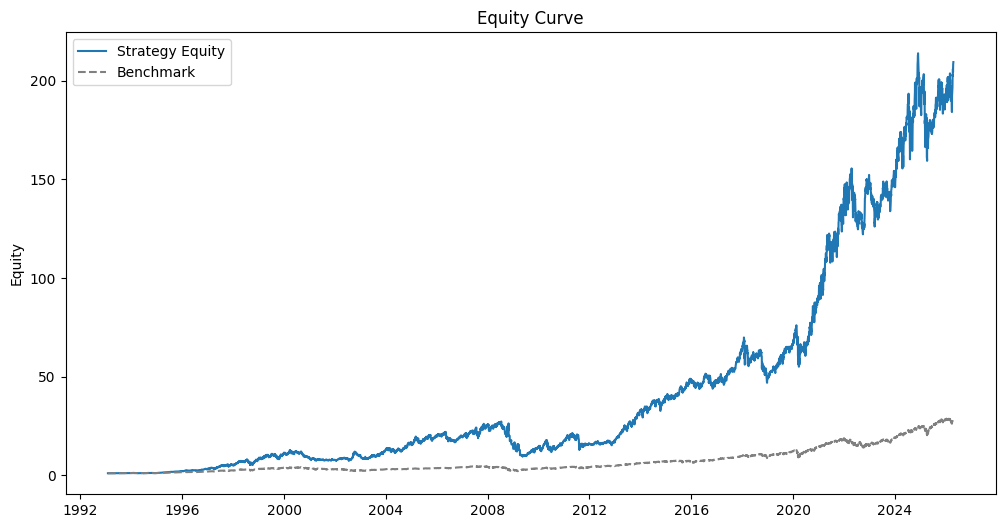

shape: (34, 10)
┌──────┬──────────┬──────────┬───────────┬───┬───────────┬──────────┬───────────┬──────────┐
│ year ┆ sortino  ┆ sharpe   ┆ ir        ┆ … ┆ maxdd     ┆ mfe      ┆ mae       ┆ win_rate │
│ ---  ┆ ---      ┆ ---      ┆ ---       ┆   ┆ ---       ┆ ---      ┆ ---       ┆ ---      │
│ i32  ┆ f64      ┆ f64      ┆ f64       ┆   ┆ f64       ┆ f64      ┆ f64       ┆ f64      │
╞══════╪══════════╪══════════╪═══════════╪═══╪═══════════╪══════════╪═══════════╪══════════╡
│ 1993 ┆ 1.91945  ┆ 1.147361 ┆ 0.147113  ┆ … ┆ -0.051409 ┆ 0.014336 ┆ -0.007019 ┆ 0.714286 │
│ 1994 ┆ 0.193393 ┆ 0.122697 ┆ 0.154939  ┆ … ┆ -0.16514  ┆ 0.016005 ┆ -0.013828 ┆ 0.529412 │
│ 1995 ┆ 7.578721 ┆ 3.856958 ┆ 3.894121  ┆ … ┆ -0.051171 ┆ 0.024723 ┆ -0.003744 ┆ 1.0      │
│ 1996 ┆ 2.651652 ┆ 1.637369 ┆ 1.663561  ┆ … ┆ -0.147503 ┆ 0.025415 ┆ -0.014185 ┆ 0.722222 │
│ 1997 ┆ 2.577854 ┆ 1.554302 ┆ 1.572724  ┆ … ┆ -0.218257 ┆ 0.034618 ┆ -0.02294  ┆ 0.647059 │
│ …    ┆ …        ┆ …        ┆ …         ┆ … ┆ …      

In [7]:
import backtest as bt

stats = bt.Backtest(
    df.rename({'date':'ts'}),
    bt.Rank(signal_expr, gate_expr),
    bt.SimpleLeverage(2, bt.TopN(4,2, bt.EqualWeight('ts','symbol','close'))),
    bt.MaxDrawdown(1,.3,1,.05),
    21,
    1,
    'SPY',
).run().report(True).drop_nans('sortino')
print(stats)

In [8]:
print(stats['maxdd'].min())
print(stats['sortino'].mean())

-0.48584043918455333
1.444113456853697
